# Imports

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


In [6]:

# Select GPU if available.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Convert MNIST images to tensors.
transform = transforms.ToTensor()

# Load the MNIST training dataset.
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

# Create mini-batches for training.
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

# Show one batch of MNIST images.
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([128, 1, 28, 28])
Label batch shape: torch.Size([128])


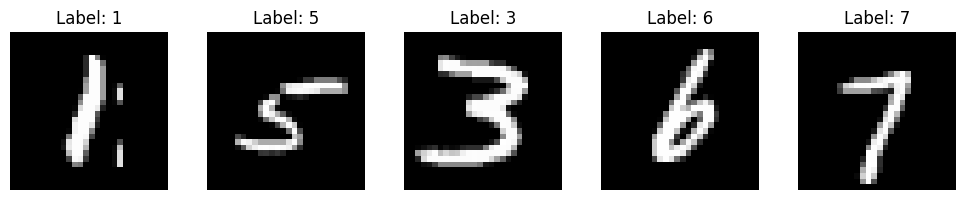

In [7]:
# Get one batch of MNIST images and labels.
images, labels = next(iter(train_loader))

# Plot the first five images in the batch.
plt.figure(figsize=(10, 2))

for i in range(5):
    # Show one grayscale digit image.
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Part 1: Variational Autoencoder

A Variational Autoencoder learns a compressed latent representation of an image.

Instead of encoding an image into one fixed vector, the encoder predicts a distribution:


In [8]:
# Define the size of the latent space.
latent_dim = 20

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        # Flattened MNIST images have 28 * 28 = 784 pixels.
        self.input_dim = 28 * 28

        # The encoder compresses the image into hidden features.
        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, 400),
            nn.ReLU()
        )

        # Predict the mean of the latent distribution.
        self.fc_mu = nn.Linear(400, latent_dim)

        # Predict the log variance of the latent distribution.
        self.fc_logvar = nn.Linear(400, latent_dim)

        # The decoder maps latent vectors back to image space.
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, self.input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        # Convert image pixels into hidden features.
        h = self.encoder(x)

        # Return the parameters of the latent distribution.
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # Convert log variance into standard deviation.
        std = torch.exp(0.5 * logvar)

        # Sample random noise with the same shape as std.
        eps = torch.randn_like(std)

        # Create a differentiable latent sample.
        return mu + eps * std

    def decode(self, z):
        # Convert latent vector back into image pixels.
        return self.decoder(z)

    def forward(self, x):
        # Flatten images from [B, 1, 28, 28] to [B, 784].
        x = x.view(-1, self.input_dim)

        # Encode image into latent distribution parameters.
        mu, logvar = self.encode(x)

        # Sample latent vector using the reparameterization trick.
        z = self.reparameterize(mu, logvar)

        # Decode latent vector into reconstructed image.
        recon_x = self.decode(z)

        return recon_x, mu, logvar

### VAE Loss

The VAE loss has two parts:

Reconstruction loss + KL divergence

The reconstruction loss checks whether the output image looks like the input image.

The KL divergence regularizes the latent space so that we can sample from it later.

In [9]:
def vae_loss(recon_x, x, mu, logvar):
    # Flatten original images to match the reconstruction shape.
    x = x.view(-1, 28 * 28)

    # Measure how well the decoder reconstructs the input image.
    reconstruction_loss = F.binary_cross_entropy(
        recon_x,
        x,
        reduction="sum"
    )

    # Regularize the latent distribution toward a standard normal distribution.
    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    # Combine reconstruction quality and latent space regularization.
    total_loss = reconstruction_loss + kl_divergence

    return total_loss, reconstruction_loss, kl_divergence

### Train VAE

In [10]:
# Create the VAE model.
vae = VAE(latent_dim).to(device)

# Create the optimizer.
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

# Define the number of training epochs.
num_epochs = 10

# Train the VAE.
for epoch in range(num_epochs):
    # Set the model to training mode.
    vae.train()

    # Store total loss for this epoch.
    total_loss = 0

    for images, _ in train_loader:
        # Move images to CPU or GPU.
        images = images.to(device)

        # Reconstruct images with the VAE.
        recon_images, mu, logvar = vae(images)

        # Compute the VAE loss.
        loss, recon_loss, kl_loss = vae_loss(recon_images, images, mu, logvar)

        # Reset gradients.
        optimizer.zero_grad()

        # Compute gradients.
        loss.backward()

        # Update model parameters.
        optimizer.step()

        # Add batch loss.
        total_loss += loss.item()

    # Compute average loss per image.
    avg_loss = total_loss / len(train_loader.dataset)

    # Print training progress.
    print(f"Epoch {epoch + 1}, loss per image: {avg_loss:.2f}")

Epoch 1, loss per image: 163.61
Epoch 2, loss per image: 121.01
Epoch 3, loss per image: 114.36
Epoch 4, loss per image: 111.43
Epoch 5, loss per image: 109.75
Epoch 6, loss per image: 108.59
Epoch 7, loss per image: 107.78
Epoch 8, loss per image: 107.15
Epoch 9, loss per image: 106.65
Epoch 10, loss per image: 106.23


### Reconstruction

The VAE first tries to reconstruct real MNIST images.

If the reconstruction is good, the model has learned a useful latent representation.

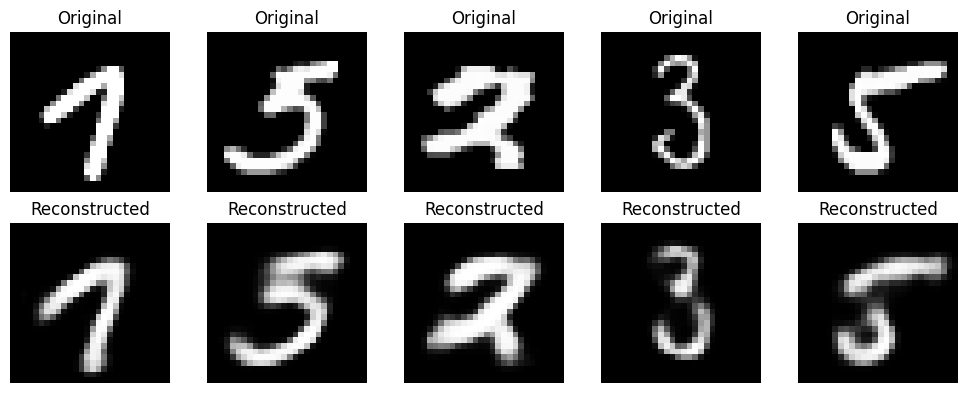

In [11]:
# Set the model to evaluation mode.
vae.eval()

# Get one batch of images.
images, labels = next(iter(train_loader))

# Move images to CPU or GPU.
images = images.to(device)

# Disable gradient computation for visualization.
with torch.no_grad():
    # Reconstruct the images.
    recon_images, _, _ = vae(images)

# Move tensors back to CPU.
images = images.cpu()
recon_images = recon_images.cpu().view(-1, 1, 28, 28)

# Create a figure for original and reconstructed images.
plt.figure(figsize=(10, 4))

for i in range(5):
    # Plot original image.
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Plot reconstructed image.
    plt.subplot(2, 5, i + 6)
    plt.imshow(recon_images[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Sampling New Images

After training, we can sample random vectors from the latent space.

The decoder turns these latent vectors into new digit images.

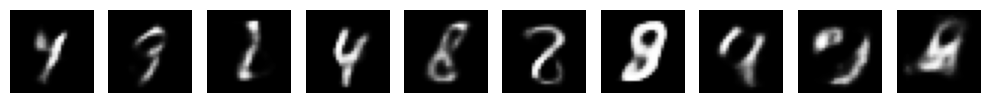

In [12]:
# Set the model to evaluation mode.
vae.eval()

# Sample random latent vectors from a standard normal distribution.
z = torch.randn(10, latent_dim).to(device)

# Decode latent vectors into images.
with torch.no_grad():
    generated_images = vae.decode(z)

# Reshape generated images to MNIST image format.
generated_images = generated_images.cpu().view(-1, 1, 28, 28)

# Plot generated images.
plt.figure(figsize=(10, 2))

for i in range(10):
    # Show one generated digit.
    plt.subplot(1, 10, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Part 2: Generative Adversarial Network

A Generative Adversarial Network trains two neural networks at the same time.

The **generator** creates fake images from random noise.

The **discriminator** tries to distinguish real MNIST images from fake generated images.

In [29]:
# Define the size of the random noise vector.
noise_dim = 100

# Flattened MNIST images have 28 * 28 = 784 pixels.
image_dim = 28 * 28

# Define the generator network.
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        # Map random noise to an MNIST-like image.
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, image_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        # Convert random noise into image pixels.
        return self.net(z)


# Define the discriminator network.
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        # Predict whether an image is real or fake.
        self.net = nn.Sequential(
            nn.Linear(image_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Flatten image and predict real/fake probability.
        x = x.view(-1, image_dim)
        return self.net(x)

In [30]:
# Create the generator.
generator = Generator().to(device)

# Create the discriminator.
discriminator = Discriminator().to(device)

# Binary cross-entropy is used for real/fake classification.
criterion = nn.BCELoss()

# Create optimizer for the generator.
optimizer_G = torch.optim.Adam(generator.parameters(), lr=2e-4)

# Create optimizer for the discriminator.
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=2e-4)

In [31]:
# Define the number of training epochs.
num_epochs = 25

# Train the GAN.
for epoch in range(num_epochs):
    for images, _ in train_loader:
        # Move real images to CPU or GPU.
        real_images = images.to(device)

        # Get the current batch size.
        batch_size_current = real_images.size(0)

        # Create labels for real images.
        real_labels = torch.ones(batch_size_current, 1).to(device)

        # Create labels for fake images.
        fake_labels = torch.zeros(batch_size_current, 1).to(device)

        # -----------------------------
        # Train discriminator
        # -----------------------------

        # Predict whether real images are real.
        real_outputs = discriminator(real_images)

        # Compute discriminator loss on real images.
        d_loss_real = criterion(real_outputs, real_labels)

        # Sample random noise for fake images.
        z = torch.randn(batch_size_current, noise_dim).to(device)

        # Generate fake images.
        fake_images = generator(z)

        # Predict whether fake images are fake.
        fake_outputs = discriminator(fake_images.detach())

        # Compute discriminator loss on fake images.
        d_loss_fake = criterion(fake_outputs, fake_labels)

        # Combine real and fake discriminator loss.
        d_loss = d_loss_real + d_loss_fake

        # Reset discriminator gradients.
        optimizer_D.zero_grad()

        # Compute discriminator gradients.
        d_loss.backward()

        # Update discriminator parameters.
        optimizer_D.step()

        # -----------------------------
        # Train generator
        # -----------------------------

        # Predict whether fake images are real.
        fake_outputs = discriminator(fake_images)

        # Generator wants fake images to be classified as real.
        g_loss = criterion(fake_outputs, real_labels)

        # Reset generator gradients.
        optimizer_G.zero_grad()

        # Compute generator gradients.
        g_loss.backward()

        # Update generator parameters.
        optimizer_G.step()

    # Print training progress.
    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"D Loss: {d_loss.item():.4f}, "
        f"G Loss: {g_loss.item():.4f}"
    )

Epoch [1/25], D Loss: 0.0209, G Loss: 6.3261
Epoch [2/25], D Loss: 0.0069, G Loss: 6.5662
Epoch [3/25], D Loss: 0.0026, G Loss: 8.2165
Epoch [4/25], D Loss: 0.0058, G Loss: 7.6451
Epoch [5/25], D Loss: 0.0032, G Loss: 9.1731
Epoch [6/25], D Loss: 0.0048, G Loss: 11.9819
Epoch [7/25], D Loss: 0.0053, G Loss: 7.9961
Epoch [8/25], D Loss: 0.0020, G Loss: 10.0927
Epoch [9/25], D Loss: 0.0047, G Loss: 8.4083
Epoch [10/25], D Loss: 0.0036, G Loss: 9.5697
Epoch [11/25], D Loss: 0.0041, G Loss: 9.7380
Epoch [12/25], D Loss: 0.0032, G Loss: 11.9959
Epoch [13/25], D Loss: 0.0283, G Loss: 8.6860
Epoch [14/25], D Loss: 0.0314, G Loss: 8.2551
Epoch [15/25], D Loss: 0.0373, G Loss: 8.6224
Epoch [16/25], D Loss: 0.0424, G Loss: 10.6030
Epoch [17/25], D Loss: 0.0015, G Loss: 10.7451
Epoch [18/25], D Loss: 0.0403, G Loss: 8.3011
Epoch [19/25], D Loss: 0.0477, G Loss: 7.0783
Epoch [20/25], D Loss: 0.0470, G Loss: 8.8132
Epoch [21/25], D Loss: 0.0096, G Loss: 8.8779
Epoch [22/25], D Loss: 0.0006, G Loss:

### Generating Images with the GAN

After training, the generator can create new digit images from random noise.

The generator does not copy training images directly.

It learns to transform noise into MNIST-like samples.

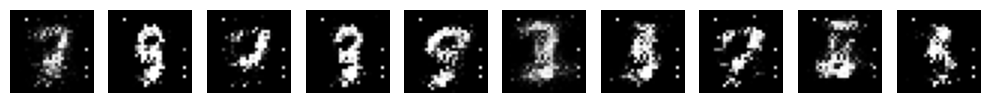

In [32]:
# Set generator to evaluation mode.
generator.eval()

# Sample random noise vectors.
z = torch.randn(10, noise_dim).to(device)

# Generate fake images.
with torch.no_grad():
    generated_images = generator(z)

# Reshape generated images to MNIST format.
generated_images = generated_images.cpu().view(-1, 1, 28, 28)

# Plot generated images.
plt.figure(figsize=(10, 2))

for i in range(10):
    # Show one generated image.
    plt.subplot(1, 10, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Part 3: Diffusion Model

A diffusion model learns to generate images by reversing a noise process.

During training, we take a clean MNIST image and add noise to it.

The model receives the noisy image and the noise level.

Its task is to predict the noise that was added.

###  Diffusion Setup


In [36]:
# Define the number of diffusion steps.
T = 100

# Create a linear noise schedule.
betas = torch.linspace(1e-4, 0.02, T).to(device)

# Compute alpha values.
alphas = 1.0 - betas

# Compute cumulative product of alphas.
alpha_bars = torch.cumprod(alphas, dim=0)

### Noise Schedule

The noise schedule controls how much noise is added at each step.

At early steps, only a little noise is added.

At later steps, the image becomes almost pure noise.

In [37]:
def add_noise(x0, t):
    # Sample random Gaussian noise with the same shape as the image.
    noise = torch.randn_like(x0)

    # Get alpha_bar values for the selected timesteps.
    alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)

    # Create the noisy image using the forward diffusion formula.
    xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * noise

    # Return the noisy image and the true noise.
    return xt, noise

### Forward Diffusion

This function simulates the forward process.

It takes a clean image and adds noise depending on the timestep `t`.

The model will later learn to predict this noise.

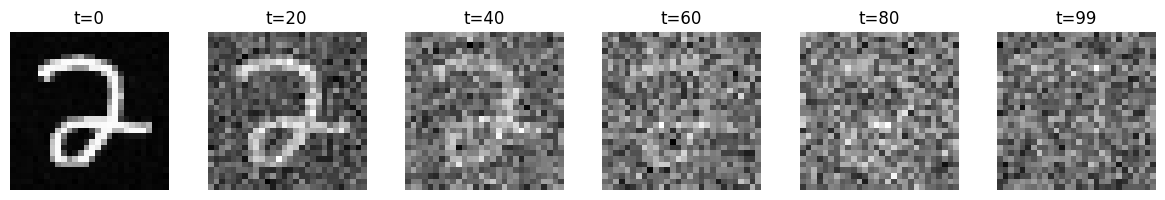

In [38]:
# Get one batch of MNIST images.
images, _ = next(iter(train_loader))

# Move images to CPU or GPU.
images = images.to(device)

# Select one image for visualization.
x0 = images[:1]

# Select different noise levels.
timesteps = torch.tensor([0, 20, 40, 60, 80, 99]).to(device)

# Create a figure.
plt.figure(figsize=(12, 2))

for i, t in enumerate(timesteps):
    # Add noise at timestep t.
    noisy_image, _ = add_noise(x0, t.view(1))

    # Plot the noisy image.
    plt.subplot(1, len(timesteps), i + 1)
    plt.imshow(noisy_image[0].detach().cpu().squeeze(), cmap="gray")
    plt.title(f"t={t.item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
class SimpleDiffusionModel(nn.Module):
    def __init__(self, T):
        super().__init__()

        # Embed the timestep into a small vector.
        self.time_embedding = nn.Embedding(T, 28 * 28)

        # Predict noise from the noisy image and timestep.
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1)
        )

    def forward(self, x, t):
        # Convert timestep IDs into image-shaped embeddings.
        t_emb = self.time_embedding(t).view(-1, 1, 28, 28)

        # Concatenate noisy image and timestep embedding.
        x = torch.cat([x, t_emb], dim=1)

        # Predict the noise added to the image.
        return self.net(x)

In [43]:
# Create the diffusion model.
diffusion_model = SimpleDiffusionModel(T).to(device)

# Create the optimizer.
optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=1e-3)

# Define the number of training epochs.
num_epochs = 25

# Train the diffusion model.
for epoch in range(num_epochs):
    # Set model to training mode.
    diffusion_model.train()

    # Store total loss for this epoch.
    total_loss = 0

    for images, _ in train_loader:
        # Move images to CPU or GPU.
        images = images.to(device)

        # Get current batch size.
        batch_size_current = images.size(0)

        # Sample random timesteps for each image.
        t = torch.randint(0, T, (batch_size_current,), device=device)

        # Add noise to the clean images.
        noisy_images, noise = add_noise(images, t)

        # Predict the added noise.
        predicted_noise = diffusion_model(noisy_images, t)

        # Compare predicted noise with true noise.
        loss = F.mse_loss(predicted_noise, noise)

        # Reset gradients.
        optimizer.zero_grad()

        # Compute gradients.
        loss.backward()

        # Update model parameters.
        optimizer.step()

        # Add batch loss.
        total_loss += loss.item()

    # Compute average loss.
    avg_loss = total_loss / len(train_loader)

    # Print training progress.
    print(f"Epoch {epoch + 1}, loss: {avg_loss:.4f}")

Epoch 1, loss: 0.1980
Epoch 2, loss: 0.0996
Epoch 3, loss: 0.0865
Epoch 4, loss: 0.0817
Epoch 5, loss: 0.0784
Epoch 6, loss: 0.0751
Epoch 7, loss: 0.0716
Epoch 8, loss: 0.0666
Epoch 9, loss: 0.0632
Epoch 10, loss: 0.0605
Epoch 11, loss: 0.0586
Epoch 12, loss: 0.0578
Epoch 13, loss: 0.0569
Epoch 14, loss: 0.0557
Epoch 15, loss: 0.0553
Epoch 16, loss: 0.0551
Epoch 17, loss: 0.0541
Epoch 18, loss: 0.0541
Epoch 19, loss: 0.0538
Epoch 20, loss: 0.0533
Epoch 21, loss: 0.0530
Epoch 22, loss: 0.0529
Epoch 23, loss: 0.0529
Epoch 24, loss: 0.0525
Epoch 25, loss: 0.0523


###  Generate New Images

In [44]:
@torch.no_grad()
def sample_images(model, num_images=10):
    # Start with pure Gaussian noise.
    x = torch.randn(num_images, 1, 28, 28).to(device)

    # Remove noise step by step.
    for t in reversed(range(T)):
        # Create timestep tensor.
        t_tensor = torch.full((num_images,), t, device=device, dtype=torch.long)

        # Predict the noise at this timestep.
        predicted_noise = model(x, t_tensor)

        # Get beta and alpha values for this timestep.
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]

        # Estimate the previous image state.
        x = (1 / torch.sqrt(alpha_t)) * (
            x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * predicted_noise
        )

        # Add noise except at the final step.
        if t > 0:
            noise = torch.randn_like(x)
            x = x + torch.sqrt(beta_t) * noise

    # Clamp values to valid image range.
    x = torch.clamp(x, 0, 1)

    return x

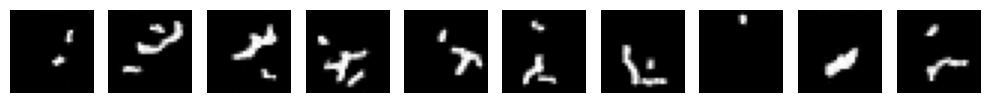

In [50]:
# Set model to evaluation mode.
diffusion_model.eval()

# Generate new images.
generated_images = sample_images(diffusion_model, num_images=10)

# Move images to CPU.
generated_images = generated_images.cpu()

# Plot generated images.
plt.figure(figsize=(10, 2))

for i in range(10):
    # Show one generated image.
    plt.subplot(1, 10, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()